In [1]:
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

#from rdkit.Chem import AllChem
#from rdkit.Chem.Draw import IPythonConsole
#from rdkit.Chem import rdMolDescriptors
#from rdkit.Chem import Descriptors
#from rdkit.Chem.Draw import IPythonConsole
#from rdkit import DataStructs
#from rdkit.DataStructs import VectCollection
#from rdkit.Chem import PandasTools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the large covalent and non-covalent dataset
df_large_cov = pd.read_csv('combined_covalent_noncovalent_dataset.csv')
df_large_cov['Structure'] = df_large_cov['smiles'].apply(lambda x: Chem.MolFromSmiles(x))
df_large_cov.drop(columns=['label'], inplace=True)
df_large_cov['source'] = 'open_database'

In [3]:
# Covalent Warhead
gen_set_1 = [
'COS(=O)(=O)F',
'CS(=O)(=O)F',
'C=CC(=O)N(C)C',
'C/C=C/C(=O)N(C)C',
'CNC(=O)CCl',
'CNC(=O)C(F)Cl',
'OB(O)c1ccccc1',
'O=Cc1ccccc1B(O)O',
'CC1CO1',
'C=CS(C)(=O)=O',
'C=CS(N)(=O)=O',
'C=C(C#N)C(=O)N(C)C',
'C/C=C(\C#N)C(=O)N(C)C',
'CC#CC(=O)N(C)C',
'N#CN1CCCCC1',
'N#CN1CCCC1'
]
# C4 patent non-covalent cereblon binder
gen_set_2 = [
'O=C1CCC(N2CCc3ccccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(N4CCCCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(N4CCCCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(C4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(C4CCNCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(N4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(N4CCNCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCCc3ccccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(N4CCCCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(N4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(C4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(C4CCNCC4)c(F)cc32)C(=O)N1',
"Cc1ccc(OC2CCC(=O)NC2=O)cc1",
"C[C@@H]1CN(c2ccccc2)C(=O)NC1=O",
"O=C1CCC(N2C(=O)c3cccc4cccc2c34)C(=O)N1",
"O=C1CCC(Oc2ccccn2)C(=O)N1",
"CN(c1ccccc1)C1CCC(=O)NC1=O",
"COc1cccc(OC2CCC(=O)NC2=O)c1",
"O=C1CCC(CNc2ccccc2)C(=O)N1",
"COc1ccc(OC2CCC(=O)NC2=O)cc1",
"Cc1cccc(OC2CCC(=O)NC2=O)c1",
"O=C1CCC(n2c(=O)oc3ccccc32)C(=O)N1",
"O=C1NC(=O)C2(Nc3ccccc3)CC1C2",
"O=C1NC(=O)C2(c3ccccc3)CC1C2",
"O=C1CCC(Oc2ccc(C3CCNCC3)cc2)C(=O)N1",
"Cc1ccc(OC2C[C@H](C)C(=O)NC2=O)cc1",
"O=C1CCC(Nc2ccc(C3CCNCC3)cc2)C(=O)N1",
"O=C1CCC(c2ccc(C3CCNCC3)cc2)C(=O)N1",
"O=C1CCN(c2ccc(C3CCNCC3)cc2)C(=O)N1"    
]
# C4 patent covalent cereblon binder
gen_set_3 = [
'O=C1CCC(N2Cc3cc(S(=O)(=O)F)ccc3C2=O)C(=O)N1',
'O=C1CCC(N2Cc3c(cccc3S(=O)(=O)F)C2=O)C(=O)N1',
'O=C1CCC(c2ccc(S(=O)(=O)F)cc2)C(=O)N1',
'Cc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'C[C@@H]1CN(c2ccc(S(=O)(=O)F)cc2)C(=O)NC1=O',
'O=C1CCC(Oc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(S(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(OS(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(Oc2ccc(S(=O)(=O)F)cn2)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(S(=O)(=O)F)c21',
'CN(c1cccc(S(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'CN(c1cccc(OS(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'Cc1ccc(OC2C[C@H](C)C(=O)NC2=O)cc1OS(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'O=C1CCC(CNc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(OS(=O)(=O)F)cc2)C(=O)N1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1OS(=O)(=O)F',
'O=C1CCC(Oc2ccc(OS(=O)(=O)F)cn2)C(=O)N1',
'O=C1CCC(n2c(=O)oc3c(S(=O)(=O)F)cccc32)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(OS(=O)(=O)F)c21',
'O=C1CCC(Nc2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1NC(=O)C2(Nc3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1NC(=O)C2(c3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1CCN(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(N3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2ccc(C3CCNCC3)c(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(CNc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
]

for smiles_list, label in [(gen_set_1, 1), (gen_set_2, 0), (gen_set_3, 1)]:
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        df_large_cov = pd.concat([df_large_cov, pd.DataFrame({'smiles':[smi], 'Structure':[mol], 'cov_label':[label], 'source': ['patent_&_generated']})], ignore_index=True)

df_large_cov

,smiles,cov_label,Structure,source
0,C=CC(=O)NCC(=O)Nc1ccccn1,1.0,<rdkit.Chem.rdchem.Mol object at 0x77fd42dbaea0>,open_database
1,C=CS(=O)(=O)N1CCCC(O)(COC)C1,1.0,<rdkit.Chem.rdchem.Mol object at 0x77fd42dbaf10>,open_database
2,CC(=O)NCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,0.0,<rdkit.Chem.rdchem.Mol object at 0x77fd42dbaf80>,open_database
3,O=c1ccn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O...,0.0,<rdkit.Chem.rdchem.Mol object at 0x77fd42dbaff0>,open_database
4,O=C1CC[C@@H](C(=O)NCc2cccc(S(=O)(=O)F)c2)N1,0.0,<rdkit.Chem.rdchem.Mol object at 0x77fd42dbb060>,open_database
...,...,...,...,...
8322,O=C1NC(=O)C2(c3ccc(S(=O)(=O)F)cc3)CC1C2,1.0,<rdkit.Chem.rdchem.Mol object at 0x77fd439f8eb0>,patent_&_generated
8323,O=C1CCN(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1,1.0,<rdkit.Chem.rdchem.Mol object at 0x77fd439f8f20>,patent_&_generated
8324,O=C1CCN(c2ccc(N3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1,1.0,<rdkit.Chem.rdchem.Mol object at 0x77fd439f8f90>,patent_&_generated
8325,O=C1CCC(Oc2ccc(C3CCNCC3)c(S(=O)(=O)F)c2)C(=O)N1,1.0,<rdkit.Chem.rdchem.Mol object at 0x77fd439f9000>,patent_&_generated


In [4]:
# Analyze bit usage for different fingerprint sizes and radii
for b in [1024, 2048, 4096, 8192, 16384]:
    for r in range(2,4):
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=r, fpSize=b)
        
        # Track bit usage counts
        bit_usage_counts = {}
        for x in df_large_cov['Structure']:
            mfp = fpg.GetFingerprint(x)
            for bit_idx in mfp.GetOnBits():
                bit_usage_counts[bit_idx] = bit_usage_counts.get(bit_idx, 0) + 1
        
        # Calculate statistics
        num_bits_used = len(bit_usage_counts)
        utilization = (num_bits_used / b) * 100
        usage_values = list(bit_usage_counts.values())
        
        print(f"Size {b}, Radius {r}: {num_bits_used} active bits ({utilization:.1f}% utilization)")
        print(f"  Bits used 1 time: {sum(1 for v in usage_values if v == 1)}")
        print(f"  Bits used 2-5 times: {sum(1 for v in usage_values if 2 <= v <= 5)}")
        print(f"  Bits used 6-10 times: {sum(1 for v in usage_values if 6 <= v <= 10)}")
        print(f"  Bits used >10 times: {sum(1 for v in usage_values if v > 10)}")
        print(f"  Average fragments per bit: {np.mean(usage_values):.1f}")
        print(f"  Max fragments for single bit: {max(usage_values)}")
        print()

Size 1024, Radius 2: 1024 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 0
  Bits used 6-10 times: 1
  Bits used >10 times: 1023
  Average fragments per bit: 336.6
  Max fragments for single bit: 7942

Size 1024, Radius 3: 1024 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 0
  Bits used 6-10 times: 0
  Bits used >10 times: 1024
  Average fragments per bit: 439.5
  Max fragments for single bit: 7945

Size 2048, Radius 2: 2048 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 9
  Bits used 6-10 times: 54
  Bits used >10 times: 1985
  Average fragments per bit: 169.1
  Max fragments for single bit: 7942

Size 2048, Radius 3: 2048 active bits (100.0% utilization)
  Bits used 1 time: 0
  Bits used 2-5 times: 0
  Bits used 6-10 times: 0
  Bits used >10 times: 2048
  Average fragments per bit: 222.5
  Max fragments for single bit: 7943

Size 4096, Radius 2: 4084 active bits (99.7% utilization)
  Bits us

In [5]:
# Re-create fingerprint generator with bit info tracking
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=16384)
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()

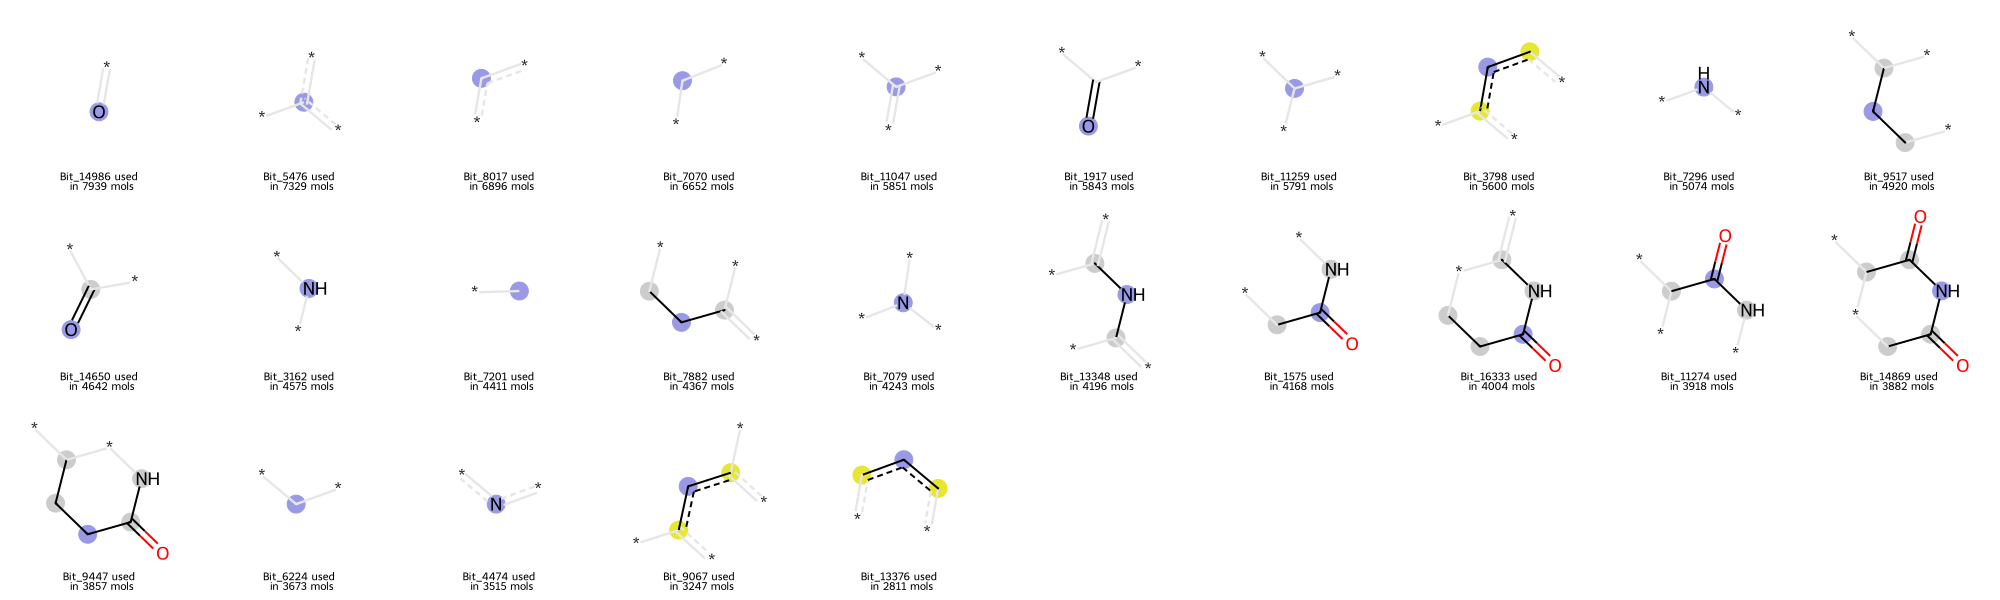

In [6]:
# Generate fingerprints to populate bit info map
bit_usage_counts = {}
all_with_label = []
for x in df_large_cov['Structure']:
    current_mfp = fpg.GetFingerprint(x, additionalOutput=ao)
    for bit_idx in current_mfp.GetOnBits():
        bit_usage_counts[bit_idx] = bit_usage_counts.get(bit_idx, 0) + 1
        fragment_tuple = (x, bit_idx, ao.GetBitInfoMap())
        all_with_label.append(fragment_tuple)

# draw most 25 unique bits sorted by usage
unique_bits = []
for mol, bit_idx, bit_info_map in all_with_label:
    if bit_idx not in [t[1] for t in unique_bits]:
        unique_bits.append((mol, bit_idx, bit_info_map))
unique_bits.sort(key=lambda x: bit_usage_counts[x[1]], reverse=True)
Draw.DrawMorganBits(unique_bits[:25], molsPerRow=10, legends=[f'Bit_{str(t[1])} used \n in {str(bit_usage_counts[t[1]])} mols' for t in unique_bits[:25]], subImgSize=(200,200))

In [7]:
# Create dataframe with fingerprint bits as columns
list_mfp = [fpg.GetFingerprint(x) for x in df_large_cov['Structure']]
bit_name = [f'Bit_{i}' for i in range(16384)]
bits = [list(l) for l in list_mfp]
df_mfp = pd.DataFrame(bits, columns=bit_name)
df_merged = pd.concat([df_large_cov, df_mfp], axis=1, join='inner')
df_merged.drop(columns=['Structure']).to_csv('covalent_noncovalent_MorganFP_bits_dataset.csv', index=False)

In [8]:
df_merged = pd.read_csv('covalent_noncovalent_MorganFP_bits_dataset.csv')

In [9]:
df_merged

,smiles,cov_label,source,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,...,Bit_16374,Bit_16375,Bit_16376,Bit_16377,Bit_16378,Bit_16379,Bit_16380,Bit_16381,Bit_16382,Bit_16383
0,C=CC(=O)NCC(=O)Nc1ccccn1,1.0,open_database,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C=CS(=O)(=O)N1CCCC(O)(COC)C1,1.0,open_database,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CC(=O)NCCCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,0.0,open_database,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,O=c1ccn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O...,0.0,open_database,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,O=C1CC[C@@H](C(=O)NCc2cccc(S(=O)(=O)F)c2)N1,0.0,open_database,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8322,O=C1NC(=O)C2(c3ccc(S(=O)(=O)F)cc3)CC1C2,1.0,patent_&_generated,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8323,O=C1CCN(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1,1.0,patent_&_generated,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8324,O=C1CCN(c2ccc(N3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1,1.0,patent_&_generated,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8325,O=C1CCC(Oc2ccc(C3CCNCC3)c(S(=O)(=O)F)c2)C(=O)N1,1.0,patent_&_generated,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df_merged_nongen = df_merged[df_merged['source'] == 'open_database']
X = df_merged_nongen.drop(columns=['smiles', 'cov_label', 'source'])
y = df_merged_nongen['cov_label']

In [12]:
df_merged_gen = df_merged[df_merged['source'] == 'patent_&_generated']
X_gen = df_merged_gen.drop(columns=['smiles', 'cov_label', 'source'])
y_gen = df_merged_gen['cov_label']

In [13]:
len(X), len(X_gen)

(8249, 78)

In [10]:
from sklearn.model_selection import train_test_split

# Scaffold split utilities (Bemis–Murcko)
def compute_scaffold(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split_indices(smiles_list, test_ratio=0.2, seed=42):
    """Return train/test indices using scaffold split for better generalization."""
    rng = np.random.default_rng(seed)
    scaffold_to_indices = {}
    for i, smi in enumerate(smiles_list):
        scaf = compute_scaffold(smi)
        scaffold_to_indices.setdefault(scaf, []).append(i)
    # Shuffle scaffolds deterministically
    scaffolds = list(scaffold_to_indices.keys())
    rng.shuffle(scaffolds)
    n = len(smiles_list)
    target_test = int(round(test_ratio * n))
    test_indices, train_indices = [], []
    covered = set()
    for scaf in scaffolds:
        bucket = scaffold_to_indices[scaf]
        if len(test_indices) < target_test:
            test_indices.extend(bucket)
        else:
            train_indices.extend(bucket)
        covered.update(bucket)
    assert len(covered) == n, "Scaffold split did not cover all samples"
    return np.array(train_indices), np.array(test_indices)

train_idx, test_idx = scaffold_split_indices(df_merged_nongen['smiles'].tolist(), test_ratio=0.2, seed=42)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [11]:
from sklearn.metrics import accuracy_score, matthews_corrcoef
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # 1. Define the search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
    }
    # 2. Initialize model with suggested params
    model = XGBClassifier(**param, random_state=42, eval_metric='logloss')
    
    # 3. Use Cross-Validation to get a score (using MCC as our metric)
    # We want to maximize this score
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='matthews_corrcoef').mean()
    
    return score

# 4. Create a "study" and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # 50 trials is usually a good start

print(f"Best MCC: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

/home/haolan/anaconda3/envs/deepchem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-31 20:36:17,412] A new study created in memory with name: no-name-3409bb7f-4944-473a-9baa-97739c554b5d
[I 2025-12-31 20:45:04,146] Trial 0 finished with value: 0.9812811402988656 and parameters: {'n_estimators': 851, 'max_depth': 4, 'learning_rate': 0.018559016596366985, 'subsample': 0.6031130504614686, 'colsample_bytree': 0.9154567264146907, 'gamma': 3.2694212037920146e-08}. Best is trial 0 with value: 0.9812811402988656.
[I 2025-12-31 20:52:24,634] Trial 1 finished with value: 0.9800633740155632 and parameters: {'n_estimators': 696, 'max_depth': 6, 'learning_rate': 0.18947099438323073, 'subsample': 0.5303230639029575, 'colsample_bytree': 0.6925771888495634, 'gamma': 2.1861219716637787e-08}. Best is trial 0 

Best MCC: 0.9834
Best Params: {'n_estimators': 167, 'max_depth': 5, 'learning_rate': 0.05200862871789219, 'subsample': 0.875263135230189, 'colsample_bytree': 0.8076860968712648, 'gamma': 0.002003979702678432}


In [13]:
study.best_params

{'n_estimators': 167,
 'max_depth': 5,
 'learning_rate': 0.05200862871789219,
 'subsample': 0.875263135230189,
 'colsample_bytree': 0.8076860968712648,
 'gamma': 0.002003979702678432}

In [12]:
best_xgb = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
best_xgb.fit(X_train, y_train)

# Evaluation
y_pred = best_xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)    
print(f"Test MCC: {mcc:.4f} | Test ACC: {acc:.4f}")

Test MCC: 0.9877 | Test ACC: 0.9939


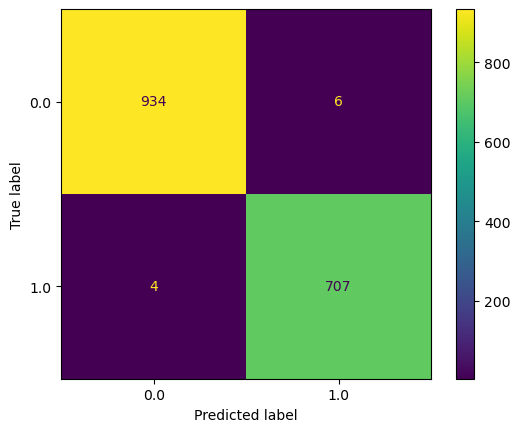

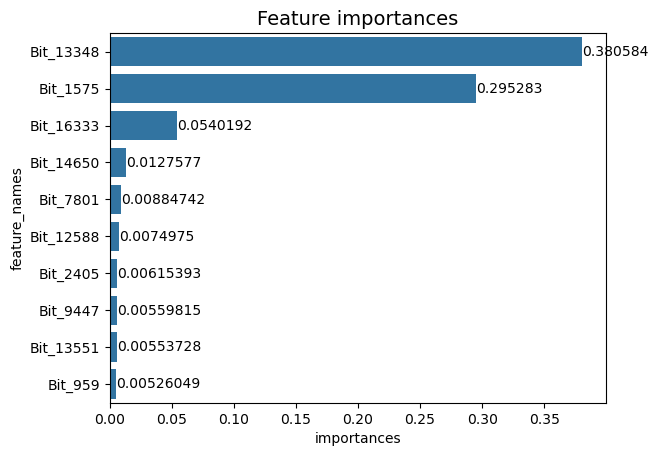

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test)
plt.show()
plt.close()
#
importances_df = pd.DataFrame({"feature_names" : best_xgb.feature_names_in_, 
                               "importances" : best_xgb.feature_importances_})
importances_df = importances_df.sort_values(by='importances', ascending=False).head(10)
g = sns.barplot(y=importances_df["feature_names"], 
                x=importances_df["importances"])
g.set_title("Feature importances", fontsize=14)
for value in g.containers:
    g.bar_label(value)
plt.show()
plt.close()

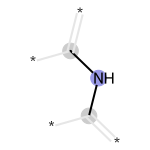

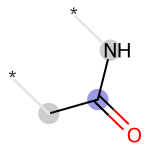

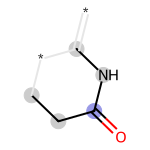

In [10]:
# Find the tuple for bit 13348 and 1575 in the unique_bits list
target_bits = [13348, 1575, 16333]
found_bits = [item for item in unique_bits if item[1] in target_bits]

if found_bits:
    for found_bit in found_bits:
        mol, bit_id, bit_info = found_bit
        display(Draw.DrawMorganBit(mol, bitId=bit_id, bitInfo=bit_info))

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef
#
best_params = {'n_estimators': 167,
'max_depth': 5,
'learning_rate': 0.05200862871789219,
'subsample': 0.875263135230189,
'colsample_bytree': 0.8076860968712648,
'gamma': 0.002003979702678432}
#
best_xgb = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
best_xgb.fit(X, y)

# Evaluation
y_pred = best_xgb.predict(X_gen)
acc = accuracy_score(y_gen, y_pred)
mcc = matthews_corrcoef(y_gen, y_pred)    
print(f"Test MCC: {mcc:.4f} | Test ACC: {acc:.4f}")

Test MCC: 0.5284 | Test ACC: 0.6923


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.svm import SVC

# Metrics storage
svc_mcc_scores = []
svc_acc_scores = []
trained_svc_models = []

# Hyperparameter grid for SVM
# Note: For high-dimensional fingerprints, 'linear' and 'rbf' are the most common kernels
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

for i in [42, 21, 0]:
    print(f"\n--- SVC Seed: {i} ---")
    
    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.8, test_size=0.2, random_state=i, stratify=y
    )

    # Initialize SVC
    # probability=True allows you to calculate ROC-AUC or soft-voting later
    svc_model = SVC(random_state=i, probability=True)

    # Grid Search
    grid_search = GridSearchCV(estimator=svc_model, param_grid=param_grid, cv=5)
    grid_search.fit(X_train, y_train)
    
    best_svc = grid_search.best_estimator_
    
    # Evaluation
    y_pred = best_svc.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    # Save results
    svc_acc_scores.append(acc)
    svc_mcc_scores.append(mcc)
    trained_svc_models.append(best_svc)
    
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Test MCC: {mcc:.4f} | Test ACC: {acc:.4f}")

# Final Summary Statistics
print("\n--- SVC Performance Summary ---")
print(f"Mean MCC: {np.mean(svc_mcc_scores):.4f} (+/- {np.std(svc_mcc_scores):.4f})")

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Storage for metrics
mcc_scores = []
acc_scores = []
trained_rf_models = []

# Define grid (slightly optimized for bit-vectors)
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'] # Better for high-dimensional chemical data
}

for i in [42, 21, 0]:
    print(f"\n--- Running Seed: {i} ---")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.8, test_size=0.2, random_state=i, stratify=y
    )

    # Initialize Grid Search with parallel processing
    rf_clf = RandomForestClassifier(random_state=i)
    grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid, cv=5)
    
    grid_search.fit(X_train, y_train)
    best_rf_clf = grid_search.best_estimator_
    
    # Evaluation
    y_pred = best_rf_clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    matt = matthews_corrcoef(y_test, y_pred)
    
    # Store results
    acc_scores.append(acc)
    mcc_scores.append(matt)
    trained_rf_models.append(best_rf_clf)
    
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Test MCC: {matt:.4f} | Test ACC: {acc:.4f}")

# Final Summary
print("\n--- RF Performance Summary ---")
print(f"Average MCC: {np.mean(mcc_scores):.4f} (+/- {np.std(mcc_scores):.4f})")

In [ ]:
from xgboost import XGBClassifier

# Metrics storage
xgb_mcc_scores = []
xgb_acc_scores = []
trained_xgb_models = []

# Hyperparameter grid optimized for high-dimensional fingerprints
param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6],           # Shallower trees prevent overfitting bit-vectors
    'n_estimators': [200, 500],
    'subsample': [0.8],
    'colsample_bytree': [0.7, 0.9], # Randomly select bits for each tree
    'gamma': [0, 0.1]
}

# Calculate class weight once (assuming y is consistent)
pos_weight = (y == 0).sum() / (y == 1).sum()

for i in [42, 21, 0]:
    print(f"\n--- XGBoost Seed: {i} ---")
    
    # Stratified split to keep class ratios identical across seeds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.8, test_size=0.2, random_state=i, stratify=y
    )

    # Initialize XGBoost
    xgb_model = XGBClassifier(
        objective='binary:logistic',
        random_state=i,
        scale_pos_weight=pos_weight,
        eval_metric='logloss'
    )

    # Search for best parameters on this split
    grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5)
    grid_search.fit(X_train, y_train)
    
    best_xgb = grid_search.best_estimator_
    
    # Evaluation
    y_pred = best_xgb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    # Save results
    xgb_acc_scores.append(acc)
    xgb_mcc_scores.append(mcc)
    trained_xgb_models.append(best_xgb)
    
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Test MCC: {mcc:.4f} | Test ACC: {acc:.4f}")

# Final Summary Statistics
print("\n--- XGBoost Performance Summary ---")
print(f"Mean MCC: {np.mean(xgb_mcc_scores):.4f} (+/- {np.std(xgb_mcc_scores):.4f})")